In [1]:
# Step B: Preprocessing + Pipeline (Paper-Aligned)

import pandas as pd
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [2]:
# 1. Load saved train/test split

X_train = pd.read_csv("C:/Users/vivek/Desktop/KI_Project/Project 2/X_training.csv")
X_test = pd.read_csv("C:/Users/vivek/Desktop/KI_Project/Project 2/X_test.csv")
y_train = pd.read_csv("C:/Users/vivek/Desktop/KI_Project/Project 2/Y_training.csv").squeeze()
y_test = pd.read_csv("C:/Users/vivek/Desktop/KI_Project/Project 2/Y_test.csv").squeeze()

In [3]:
# 2. Shape check

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (811, 6)
X_test shape: (203, 6)

Train class distribution:
RiskLevel
0    0.731196
1    0.268804
Name: proportion, dtype: float64

Test class distribution:
RiskLevel
0    0.73399
1    0.26601
Name: proportion, dtype: float64


In [4]:
# 3. Define preprocessing

# All features are numeric → apply scaling

numeric_features = X_train.columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)

In [5]:
# 4. Build pipeline with XGBoost

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])

print("\nPipeline created successfully.")


Pipeline created successfully.


In [6]:
# 5. Quick test run

pipeline.fit(X_train, y_train)

y_prob = pipeline.predict_proba(X_test)[:, 1]

print("\nPipeline working. First 5 predicted probabilities:")
print(y_prob[:5])


Pipeline working. First 5 predicted probabilities:
[0.00129198 0.06311211 0.13597022 0.0001608  0.00024702]


In [7]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np


In [8]:
# 6. Define cross-validation

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


In [9]:
# 7. Define hyperparameter space

param_dist = {
    'classifier__n_estimators': [100, 200, 300, 400],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

In [10]:
# 8. Randomized Search

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=200,                    # 200 configurations
    scoring='average_precision',   # PR-AUC
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1                      # use all CPU cores
)

print("Starting hyperparameter search...\n")

Starting hyperparameter search...



In [11]:
# 9. Fit on TRAINING data only

search.fit(X_train, y_train)

# 10. Retrieve best model

best_model = search.best_estimator_

print("\n Hyperparameter tuning complete.")


Fitting 10 folds for each of 200 candidates, totalling 2000 fits

✅ Hyperparameter tuning complete.


In [12]:
# 11. Results summary

print("\nBest Parameters:")
print(search.best_params_)

print("\nBest Cross-Validated PR-AUC:")
print(search.best_score_)


Best Parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 1.0}

Best Cross-Validated PR-AUC:
0.9602087405314602


In [13]:
from sklearn.metrics import roc_curve

 #12. Find G.mean threshold instead of regular 0.5
    # 1. Get probabilities (TRAIN set)

y_train_prob = best_model.predict_proba(X_train)[:, 1]

    # 2. Compute ROC curve

fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)

    # 3. Compute G-mean

gmeans = np.sqrt(tpr * (1 - fpr))

    # 4. Find best threshold

ix = np.argmax(gmeans)
best_threshold = thresholds[ix]

print("Best Threshold (G-mean):", best_threshold)
print("G-mean:", gmeans[ix])

Best Threshold (G-mean): 0.38933635
G-mean: 0.9736459558745229


In [14]:
# 14. Testing the model and providing final metrics

y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

In [15]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, brier_score_loss, confusion_matrix
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)
mcc = matthews_corrcoef(y_test, y_test_pred)
brier = brier_score_loss(y_test, y_test_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
specificity = tn / (tn + fp)

print("\n=== Final Model Performance ===")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"MCC: {mcc:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")
print(f"Brier Score: {brier:.3f}")


=== Final Model Performance ===
Accuracy: 0.956
Precision: 0.909
Recall (Sensitivity): 0.926
Specificity: 0.966
F1-score: 0.917
MCC: 0.887
ROC-AUC: 0.968
PR-AUC: 0.945
Brier Score: 0.044


In [16]:
# 15. Checking out the positives and negatives

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Confusion Matrix:
[[144   5]
 [  4  50]]


In [17]:
# 16. Bootstrap CL - Check the confidence range of machine

from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, brier_score_loss, confusion_matrix
)

n_iterations = 1000

metrics_bootstrap = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "specificity": [],
    "f1": [],
    "mcc": [],
    "roc_auc": [],
    "pr_auc": [],
    "brier": []
}

for _ in range(n_iterations):
    # resample test set
    X_res, y_res = resample(X_test, y_test, replace=True)

    y_prob = best_model.predict_proba(X_res)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)

    # confusion matrix for specificity
    tn, fp, fn, tp = confusion_matrix(y_res, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # store metrics
    metrics_bootstrap["accuracy"].append(accuracy_score(y_res, y_pred))
    metrics_bootstrap["precision"].append(precision_score(y_res, y_pred))
    metrics_bootstrap["recall"].append(recall_score(y_res, y_pred))
    metrics_bootstrap["specificity"].append(specificity)
    metrics_bootstrap["f1"].append(f1_score(y_res, y_pred))
    metrics_bootstrap["mcc"].append(matthews_corrcoef(y_res, y_pred))
    metrics_bootstrap["roc_auc"].append(roc_auc_score(y_res, y_prob))
    metrics_bootstrap["pr_auc"].append(average_precision_score(y_res, y_prob))
    metrics_bootstrap["brier"].append(brier_score_loss(y_res, y_prob))

In [18]:
def compute_ci(values):
    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)
    mean = np.mean(values)
    return mean, lower, upper

ci_results = {}

for metric, values in metrics_bootstrap.items():
    ci_results[metric] = compute_ci(values)

# Print results
for metric, (mean, lower, upper) in ci_results.items():
    print(f"{metric.upper()}: {mean:.3f} (95% CI: {lower:.3f} – {upper:.3f})")

ACCURACY: 0.956 (95% CI: 0.926 – 0.980)
PRECISION: 0.909 (95% CI: 0.830 – 0.980)
RECALL: 0.926 (95% CI: 0.849 – 0.984)
SPECIFICITY: 0.967 (95% CI: 0.934 – 0.993)
F1: 0.917 (95% CI: 0.857 – 0.966)
MCC: 0.887 (95% CI: 0.807 – 0.952)
ROC_AUC: 0.968 (95% CI: 0.938 – 0.991)
PR_AUC: 0.945 (95% CI: 0.899 – 0.981)
BRIER: 0.044 (95% CI: 0.024 – 0.068)


SHAP values computed successfully


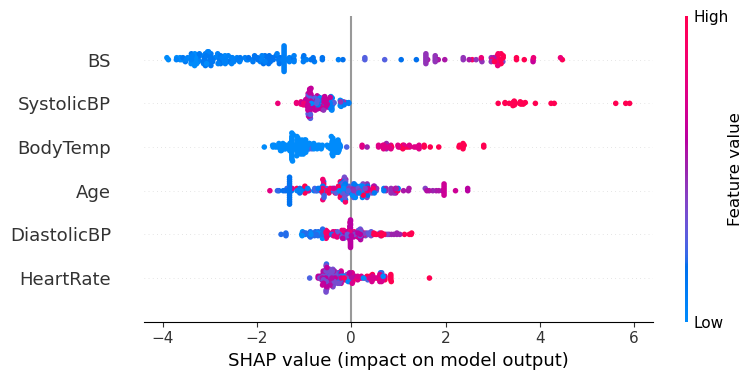

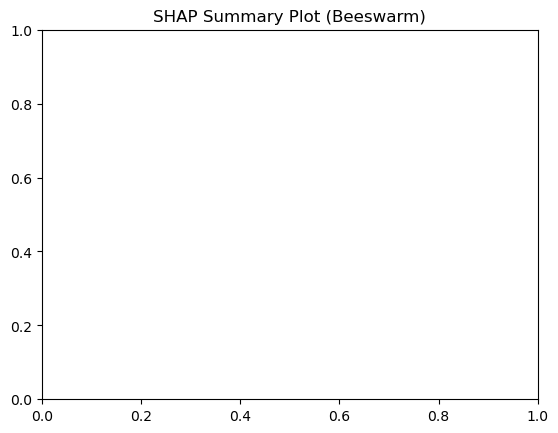

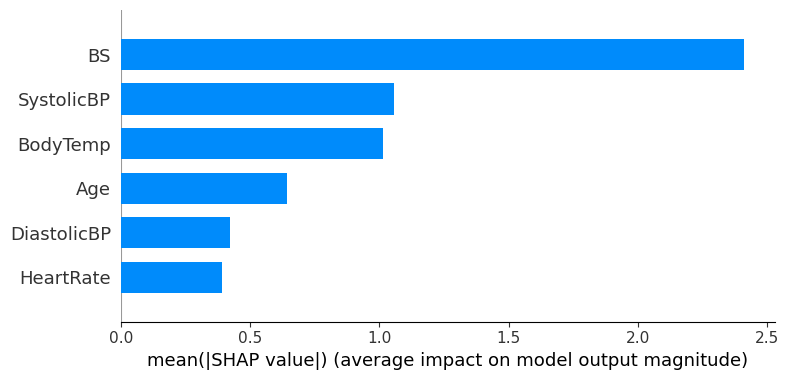

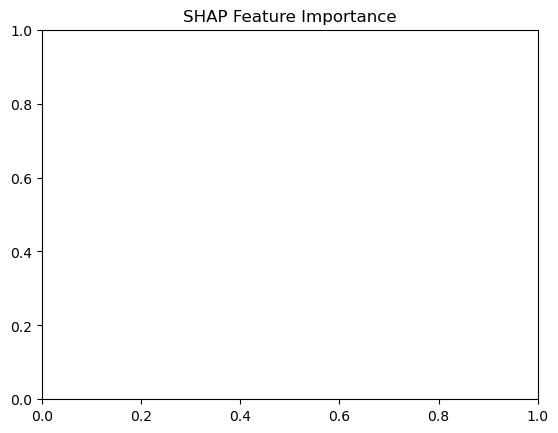

<Figure size 640x480 with 0 Axes>

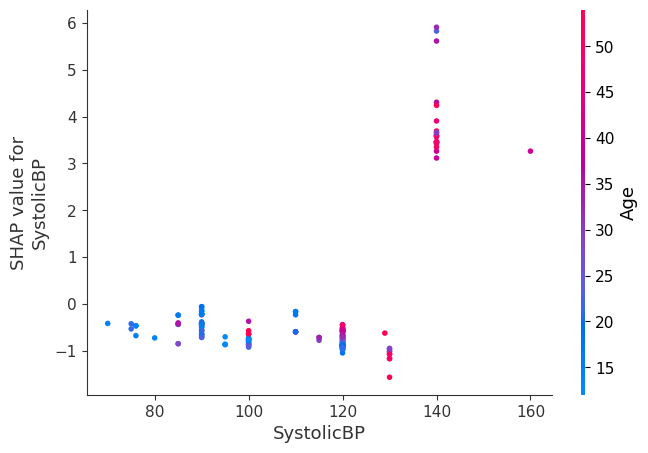

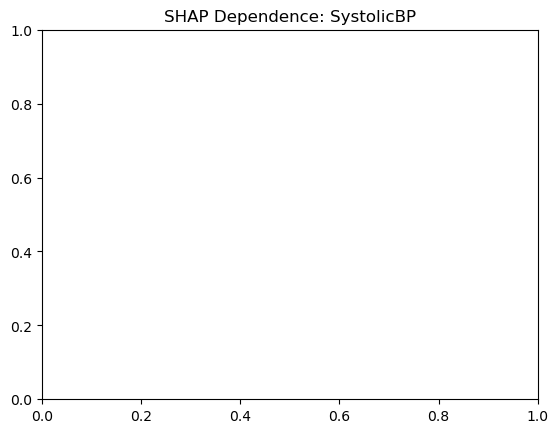

<Figure size 640x480 with 0 Axes>

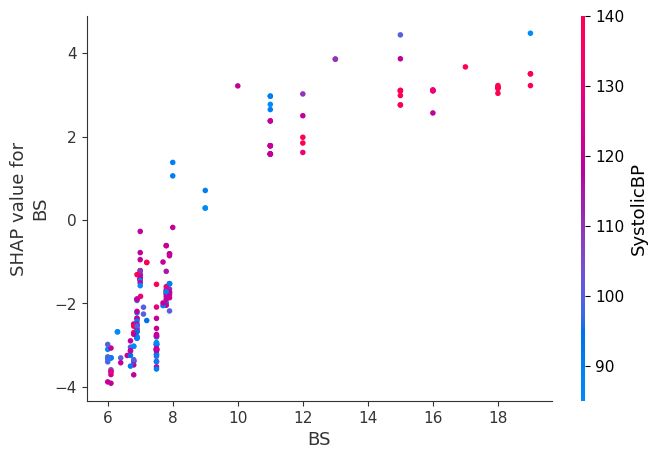

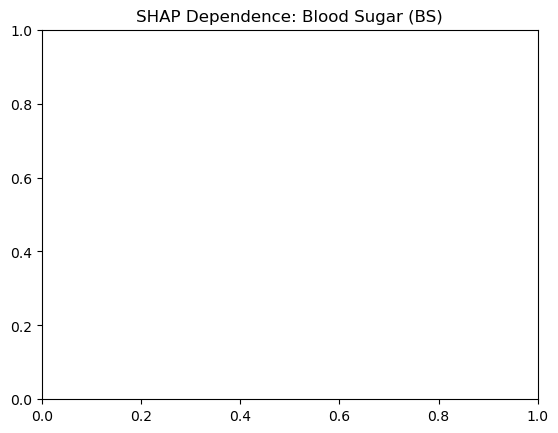

<Figure size 640x480 with 0 Axes>

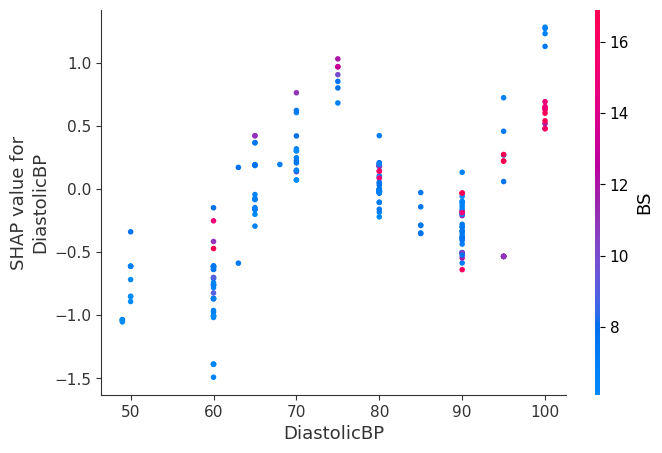

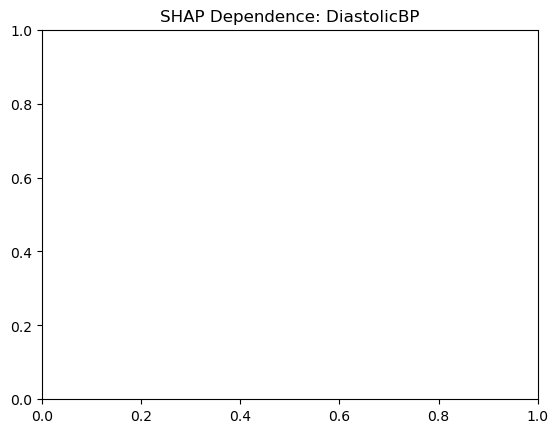

In [20]:
# 17. SHAP Interpretability

import shap
import matplotlib.pyplot as plt

    # 1. Extract model + preprocessor

model = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

    # 2. Transform test data

X_test_transformed = preprocessor.transform(X_test)

    # 3. Initialize SHAP explainer

explainer = shap.TreeExplainer(model)

    # 4. Compute SHAP values

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values computed successfully")

    # 5. Beeswarm plot (global importance)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)
plt.title("SHAP Summary Plot (Beeswarm)")
plt.show()

    # 6. Bar plot (feature importance)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.title("SHAP Feature Importance")
plt.show()

    # 7. Dependence plots (top features)

    # Systolic Blood Pressure
plt.figure()
shap.dependence_plot("SystolicBP", shap_values, X_test)
plt.title("SHAP Dependence: SystolicBP")
plt.show()

    # Blood Sugar
plt.figure()
shap.dependence_plot("BS", shap_values, X_test)
plt.title("SHAP Dependence: Blood Sugar (BS)")
plt.show()

    # Diastolic Blood Pressure
plt.figure()
shap.dependence_plot("DiastolicBP", shap_values, X_test)
plt.title("SHAP Dependence: DiastolicBP")
plt.show()